# 07 - Comparación económica exploratoria en validación

En esta etapa comparamos la política fija, Bayes Minimum Risk (BMR) y un árbol ponderado sensible al costo sobre las mismas operaciones posteriores de validation. Reutilizamos el predictor y calibrador del 06, sin volver a ajustarlos. Test permanece sin puntuar.

Ca toma los valores ilustrativos del 04: 1, 5, 10, 20, 50 y 100 unidades del dataset. No son costos observados ni escenarios finales aprobados. No elegimos Ca para maximizar el ahorro obtenido. La calibración del 06 no mejoró Brier o log-loss posteriores; mantenemos esa limitación visible al interpretar costos.

La implementación vive en src/fraud_cost/economics.py y reutiliza la matriz de costs.py. El árbol aprende acciones a partir de atributos de train, no probabilidades de fraude calibradas ni etiquetas de validación. Es una aproximación por impureza ponderada, no un algoritmo exacto de costos por ejemplo.


## 1. Fijar escenarios y verificar entradas

Verificamos los hashes del reajuste y de sus artefactos antes de cargar el modelo local. Comprobamos además que el calibrador serializado transforme las probabilidades originales en las probabilidades guardadas. No cargamos archivos joblib de procedencia desconocida.

Intervenir cuesta Ca tanto en fraude como en legítimas; aprobar fraude cuesta su monto y aprobar legítimas cuesta cero. BMR interviene si p_i × A_i > Ca y aprueba en empate. La regla fija conserva p_i ≥ 0,5.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from fraud_cost.economics import (
    verified_refit, load_economic_inputs, prepare_cost_matrices,
    compare_economic_policies, save_economic_comparison,
)
from fraud_cost.scenarios import HYPOTHETICAL_CA_GRID
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src').is_dir() and (p / 'data').is_dir())
CA_GRID = HYPOTHETICAL_CA_GRID
RANDOM_STATE = 42
predictor, scores, refit_config = verified_refit(ROOT)
print('Escenarios hipotéticos, no aprobados:', CA_GRID)


Escenarios hipotéticos, no aprobados: (1.0, 5.0, 10.0, 20.0, 50.0, 100.0)


## 2. Reconstruir atributos sin cambiar el predictor

Recuperamos train y validation del mismo manifiesto y comprobamos que IDs, tiempos, montos y etiquetas posteriores coincidan exactamente con los scores. Las operaciones de gaps y test se descartan antes de preparar atributos.

Para entrenar árboles reconstruimos el historial estrictamente anterior de train, pero aplicamos el preprocesamiento ya ajustado del 06. Para evaluación usamos su estado histórico congelado. Verificamos que XGBoost reproduzca las probabilidades originales guardadas; esto evita comparar árboles y reglas sobre entradas desalineadas.


In [2]:
train, validation_policy, scores = load_economic_inputs(ROOT, scores, refit_config)
X_train, X_policy = prepare_cost_matrices(predictor, train, validation_policy, scores)
print(f'Train: {len(train):,}; evaluación posterior: {len(scores):,}; columnas: {X_train.shape[1]:,}.')


Train: 380,815; evaluación posterior: 42,047; columnas: 2,642.


## 3. Comparar tres políticas con la misma matriz

Por cada Ca ajustamos un árbol independiente con profundidad máxima 12 y mínimo 250 operaciones por hoja, sin seleccionar esos parámetros con validation. Su objetivo de acción es 1 si y_i × A_i > Ca y su peso es |y_i × A_i − Ca|, normalizado por una constante común. Los errores ponderados reproducen el costo empírico salvo una constante, pero CART no garantiza minimizar globalmente ese costo.

Evaluamos costo total, costo administrativo, monto de fraude aprobado, recall, recall ponderado por monto y tasa de legítimas intervenidas. El ahorro usa como referencia min(aprobar todo, intervenir todo); la mejora frente a la política fija es otra comparación. Un ahorro puede ser negativo.

Añadimos el costo esperado de cada acción usando las mismas probabilidades del XGBoost. BMR es mínimo por construcción bajo esas probabilidades y supuestos, pero no necesariamente obtiene el menor costo realizado. Esta diferencia es especialmente relevante cuando existe desajuste de calibración.


In [3]:
comparison, calibration_effect, tree_diagnostics, trees, actions = compare_economic_policies(
    train, scores, X_train, X_policy, ca_grid=CA_GRID, random_state=RANDOM_STATE,
)
display(comparison[['administrative_cost_ca', 'strategy', 'cost_total_proxy', 'savings_fraction_vs_reference', 'savings_fraction_vs_fixed_proxy', 'fraud_recall', 'legitimate_block_rate']])
display(tree_diagnostics)


Ca=1: ajuste del árbol ponderado con 380,815 transacciones de train.


  Costo BMR=24,960.25; árbol=44,850.69.


Ca=5: ajuste del árbol ponderado con 380,815 transacciones de train.


  Costo BMR=65,114.85; árbol=87,286.07.


Ca=10: ajuste del árbol ponderado con 380,815 transacciones de train.


...

  Costo BMR=165,184.05; árbol=196,150.27.


Ca=100: ajuste del árbol ponderado con 380,815 transacciones de train.


  Costo BMR=198,291.02; árbol=205,672.42.


,administrative_cost_ca,strategy,cost_total_proxy,savings_fraction_vs_reference,savings_fraction_vs_fixed_proxy,fraud_recall,legitimate_block_rate
0,1.0,fixed_0_5,200631.515,-3.771601,0.000000,0.278840,0.003454
1,1.0,bmr,24960.249,0.406373,0.875592,0.862228,0.366198
2,1.0,cost_sensitive_tree,44850.690,-0.066680,0.776452,0.775214,0.350210
3,5.0,fixed_0_5,202883.515,0.034968,0.000000,0.278840,0.003454
4,5.0,bmr,65114.851,0.690276,0.679053,0.650626,0.119763
5,5.0,cost_sensitive_tree,87286.074,0.584817,0.569772,0.578115,0.124599
6,10.0,fixed_0_5,205698.515,0.191871,0.000000,0.278840,0.003454
7,10.0,bmr,88400.085,0.652702,0.570244,0.537245,0.066790
8,10.0,cost_sensitive_tree,121023.065,0.524536,0.411648,0.396836,0.074044
9,20.0,fixed_0_5,211328.515,0.169753,0.000000,0.278840,0.003454


,administrative_cost_ca,train_rows,features,depth,leaves,seconds,max_depth,min_samples_leaf,random_state
0,1.0,380815,2642,12,415,180.538866,12,250,42
1,5.0,380815,2642,12,360,146.866106,12,250,42
2,10.0,380815,2642,12,317,136.344841,12,250,42
3,20.0,380815,2642,12,243,110.376125,12,250,42
4,50.0,380815,2642,12,180,97.555027,12,250,42
5,100.0,380815,2642,12,128,69.839779,12,250,42


## 4. Medir el efecto económico de la calibración

El diagnóstico separado compara acciones BMR con probabilidades originales y calibradas. Reportamos cuántas cambian y descomponemos la diferencia de costo en administración y fraude aprobado. Un valor positivo de calibrated_minus_raw_cost indica mayor costo realizado después de calibrar para ese Ca.

No convertimos este diagnóstico en una cuarta estrategia principal ni elegimos retrospectivamente el calibrador que más ahorro produzca en estas mismas filas. Brier y log-loss agregados no determinan por sí solos el resultado económico: importan los montos y las operaciones que cruzan cada límite Ca/A_i.


In [4]:
display(calibration_effect)


,administrative_cost_ca,rows,actions_changed,additional_interventions,fewer_interventions,raw_bmr_cost,calibrated_bmr_cost,calibrated_minus_raw_cost,administrative_cost_delta,missed_fraud_amount_delta,scenario_status
0,1.0,42047,1094,0,1094,25225.644,24960.249,-265.395,-1094.0,828.605,HIPOTETICO_NO_SELECCION_DE_CALIBRADOR
1,5.0,42047,441,0,441,65684.903,65114.851,-570.052,-2205.0,1634.948,HIPOTETICO_NO_SELECCION_DE_CALIBRADOR
2,10.0,42047,242,0,242,88354.988,88400.085,45.097,-2420.0,2465.097,HIPOTETICO_NO_SELECCION_DE_CALIBRADOR
3,20.0,42047,128,1,127,118750.707,118762.070,11.363,-2520.0,2531.363,HIPOTETICO_NO_SELECCION_DE_CALIBRADOR
4,50.0,42047,47,1,46,165571.685,165184.051,-387.634,-2250.0,1862.366,HIPOTETICO_NO_SELECCION_DE_CALIBRADOR
5,100.0,42047,10,0,10,197962.022,198291.022,329.000,-1000.0,1329.000,HIPOTETICO_NO_SELECCION_DE_CALIBRADOR


## 5. Exportar evidencia y leer los compromisos

Una figura resume costo, detección de fraude e intervención de legítimas. BMR mantiene conjuntos de intervención anidados al aumentar Ca; los árboles pueden no hacerlo porque cada Ca modifica su entrenamiento. Las acciones fijas no cambian, aunque su costo administrativo sí.

Exportamos tres tablas y una configuración trazable. Los árboles y acciones por operación quedan locales e ignorados por Git; permiten auditar los costos sin sustituir el predictor del 06 ni los artefactos de la referencia anterior.


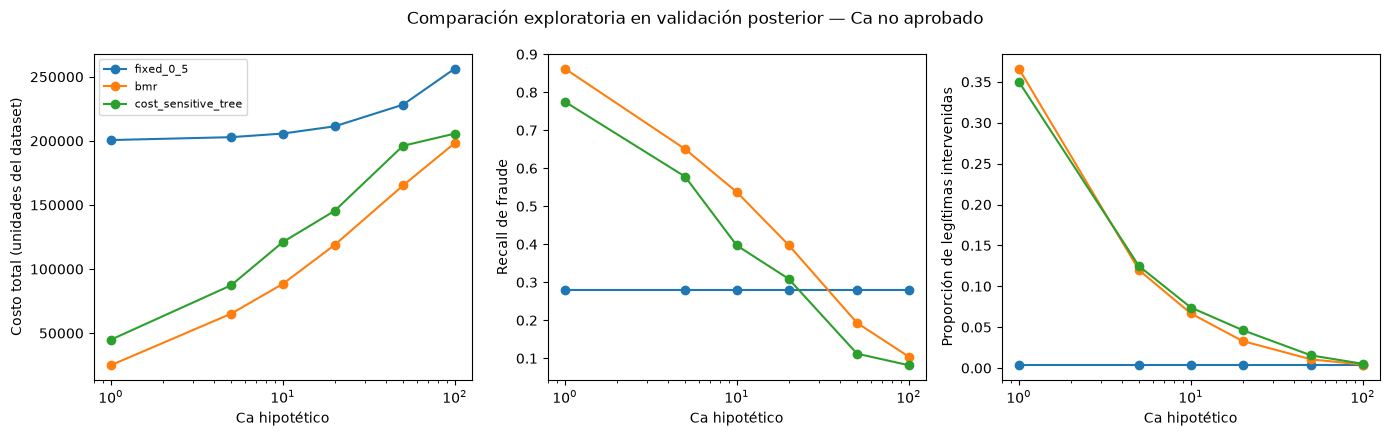

Comparación guardada. Test sin puntuar; escenarios finales y calibración pendientes de discusión.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
panels = [('cost_total_proxy', 'Costo total (unidades del dataset)'), ('fraud_recall', 'Recall de fraude'), ('legitimate_block_rate', 'Proporción de legítimas intervenidas')]
for name, block in comparison.groupby('strategy', sort=False):
    for ax, (metric, label) in zip(axes, panels):
        ax.plot(block.administrative_cost_ca, block[metric], marker='o', label=name)
for ax, (_, label) in zip(axes, panels):
    ax.set(xscale='log', xlabel='Ca hipotético', ylabel=label)
axes[0].legend(fontsize=8)
fig.suptitle('Comparación exploratoria en validación posterior — Ca no aprobado')
fig.tight_layout()
figure_path = ROOT / 'results/figures/comparacion_economica_validation.png'
fig.savefig(figure_path, dpi=160, bbox_inches='tight')
plt.show()
record = save_economic_comparison(ROOT, comparison, calibration_effect, tree_diagnostics, trees, actions, ca_grid=CA_GRID)
print('Comparación guardada. Test sin puntuar; escenarios finales y calibración pendientes de discusión.')


## 6. Lectura de la corrida y límites

En esta ventana, BMR obtiene menor costo realizado que el fijo y el árbol en los seis Ca ilustrativos. Con Ca=10, los costos son 205.698,515 para el fijo, 88.400,085 para BMR y 121.023,065 para el árbol. La reducción BMR frente al fijo es 57,02%; el ahorro de 65,27% compara con la mejor política trivial, no con el clasificador.

BMR interviene 3.522 operaciones en Ca=10, frente a 563 del fijo. Aumenta el costo administrativo, pero reduce el monto de fraude aprobado de 200.068,515 a 53.180,085. Su recall por número de fraudes es 53,72% y el ponderado por monto 79,11%, con 6,68% de legítimas intervenidas. El resultado muestra un compromiso económico, no una mejora gratuita de todas las métricas.

El árbol mejora frente al fijo en los seis escenarios, pero en Ca=1 cuesta más que intervenir todo y su ahorro trivial es negativo. La calibración reduce el costo BMR en Ca=1,5,50 y lo aumenta en Ca=10,20,100. No seleccionamos retrospectivamente otro mapeo a partir de esas diferencias.

El informe docs/07_comparacion_economica_validation.md desarrolla la evidencia y las decisiones pendientes. Los seis escenarios comparten datos y no son seis réplicas independientes; no inferimos superioridad estadística ni desempeño futuro a partir de esta corrida.

Esta es una comparación retrospectiva de desarrollo, no una estimación de pérdidas bancarias ni una conclusión final fuera de muestra. No elegimos Ca a partir del porcentaje de ahorro ni presentamos al árbol ponderado como método exacto. Antes de evaluar test debemos acordar escenarios y unidades, discutir calibración y congelar el protocolo.
